# TP Ejercicio 4 — Clientes en los supermercados de Don Francisco y Don Miguel

Simulación con distribución **Poisson**, cuyo parámetro $\lambda_t$ depende del año, mes, día de la semana y del comercio. Luego se estiman la **ECDF**, una **aproximación de la densidad de clientes** (histograma + KDE) y la **densidad empírica conjunta**.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
np.random.seed(42)

## Parámetros del modelo

Para cada fecha $t$ y comercio:

$$\lambda_t = \text{efecto anual} + \text{efecto mensual} + \text{efecto diario} + \text{efecto local}$$

In [11]:
EFECTO_ANUAL = {2023: 10, 2024: 15, 2025: 20}

EFECTO_MENSUAL = {
    1: 10, 
    2: 15, 
    3: 20,
    4: 20,
    5: 25,
    6: 25,
    7: 30,
    8: 25,
    9: 25,
    10: 20,
    11: 15,
    12: 10,
}

# weekday: lunes=0 ... domingo=6
EFECTO_DIARIO = {
    6: 10,  # domingo
    0: 20,  # lunes
    1: 30,  # martes
    2: 35,  # miércoles
    3: 30,  # jueves
    4: 20,  # viernes
    5: 10,  # sábado
}

EFECTO_LOCAL = {
    "Don Francisco": 20,
    "Don Miguel": 10,
}

In [12]:
def calcular_lambda(fechas: pd.DatetimeIndex, comercio: str) -> np.ndarray:
    """Vector de lambdas para cada fecha y comercio."""
    return (
        fechas.year.map(EFECTO_ANUAL)
        + fechas.month.map(EFECTO_MENSUAL)
        + fechas.weekday.map(EFECTO_DIARIO)
        + EFECTO_LOCAL[comercio]
    ).to_numpy()

In [13]:
def simular_clientes(comercio: str, anios=(2023, 2024, 2025)) -> pd.DataFrame:
    """Simula conteos diarios Poisson para un comercio en los años indicados."""
    fechas = pd.date_range(f"{min(anios)}-01-01", f"{max(anios)}-12-31", freq="D")
    lambdas = calcular_lambda(fechas, comercio)
    clientes = np.random.poisson(lam=lambdas)
    df = pd.DataFrame({"fecha": fechas, "clientes": clientes, "anio": fechas.year})
    return df[df["anio"].isin(anios)].reset_index(drop=True)

## (a) Simulación de clientes (2023–2025)

Para cada día se genera $N_t \sim \text{Poisson}(\lambda_t)$ en cada supermercado.

In [14]:
df_francisco = simular_clientes(comercio="Don Francisco")
df_miguel = simular_clientes(comercio="Don Miguel")

print("Don Francisco — primeras filas:")
display(df_francisco.head())
print("\nDon Miguel — primeras filas:")
display(df_miguel.head())

print("\nResumen por año — Don Francisco:")
display(df_francisco.groupby("anio")["clientes"].describe())
print("\nResumen por año — Don Miguel:")
display(df_miguel.groupby("anio")["clientes"].describe())

Don Francisco — primeras filas:


,fecha,clientes,anio
0,2023-01-01,47,2023
1,2023-01-02,65,2023
2,2023-01-03,60,2023
3,2023-01-04,77,2023
4,2023-01-05,79,2023



Don Miguel — primeras filas:


,fecha,clientes,anio
0,2023-01-01,37,2023
1,2023-01-02,58,2023
2,2023-01-03,58,2023
3,2023-01-04,62,2023
4,2023-01-05,47,2023



Resumen por año — Don Francisco:


,count,mean,std,min,25%,50%,75%,max
anio,,,,,,,,
2023,365.0,71.016438,13.724717,36.0,62.0,70.0,81.0,107.0
2024,366.0,77.300546,15.003282,40.0,66.0,77.0,88.0,124.0
2025,365.0,81.832877,14.540849,42.0,72.0,82.0,92.0,119.0



Resumen por año — Don Miguel:


,count,mean,std,min,25%,50%,75%,max
anio,,,,,,,,
2023,365.0,62.378082,13.426215,28.0,54.0,62.0,71.0,101.0
2024,366.0,66.907104,13.667364,36.0,58.0,66.0,77.0,100.0
2025,365.0,71.791781,14.294025,34.0,61.0,72.0,81.0,110.0


In [15]:
def graficar_ecdf_y_densidad(df: pd.DataFrame, comercio: str):
    """ECDF y aproximación de la densidad de clientes (histograma + KDE) por año."""
    for anio in sorted(df["anio"].unique()):
        datos = df.loc[df["anio"] == anio, "clientes"]

        plt.figure(figsize=(7, 4))
        sns.ecdfplot(datos, color="red", ls="--")
        plt.title(f"{comercio} — ECDF ({anio})")
        plt.xlabel("Número de clientes")
        plt.ylabel("Proporción acumulada")
        plt.grid(axis="y")
        plt.show()

        plt.figure(figsize=(7, 4))
        sns.histplot(
            datos,
            bins=30,
            stat="density",
            color="skyblue",
            alpha=0.5,
            label="Histograma",
        )
        sns.kdeplot(datos, color="red", label="KDE")
        plt.title(f"{comercio} — Densidad empírica de clientes ({anio})")
        plt.xlabel("Número de clientes")
        plt.ylabel("Densidad")
        plt.legend()
        plt.show()

## (b) Don Francisco — ECDF y densidad de clientes por año

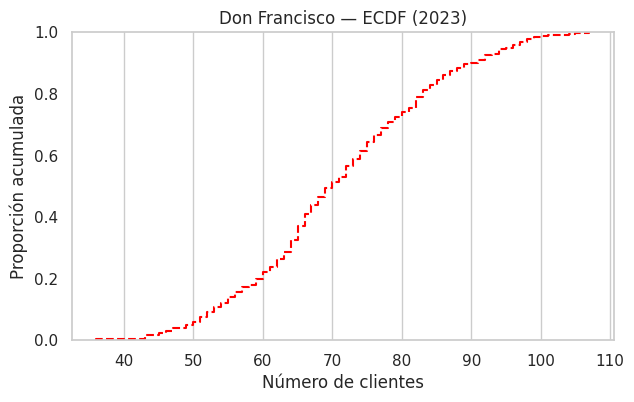

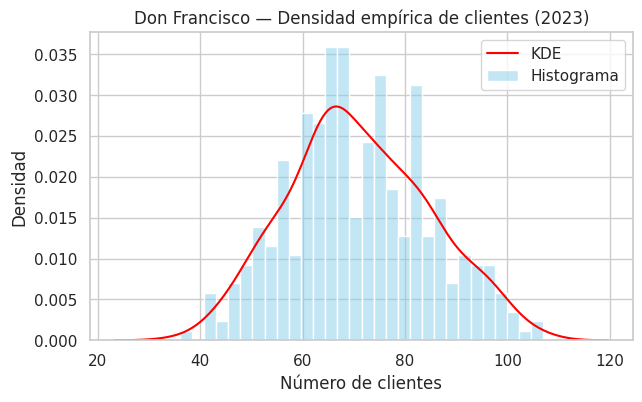

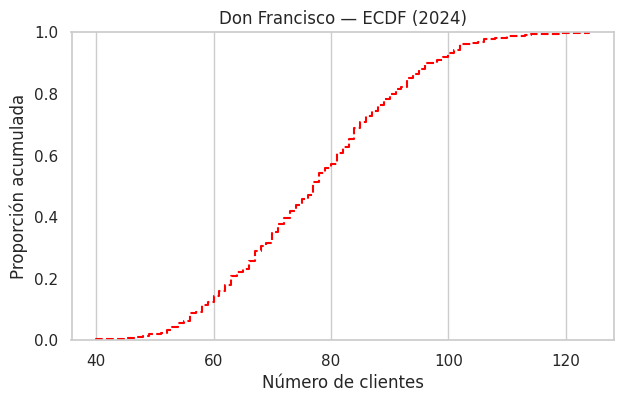

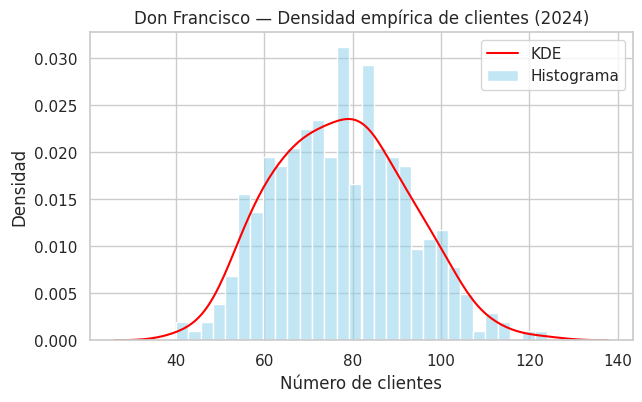

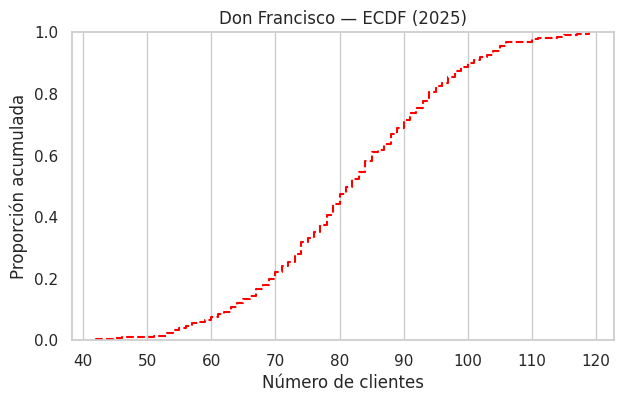

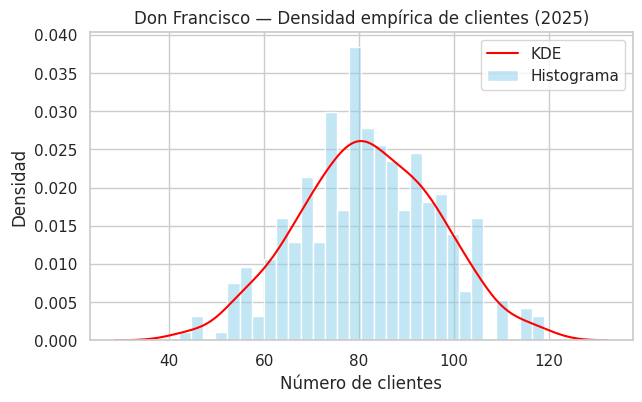

In [16]:
graficar_ecdf_y_densidad(df_francisco, "Don Francisco")

## (c) Don Miguel — ECDF y densidad de clientes por año

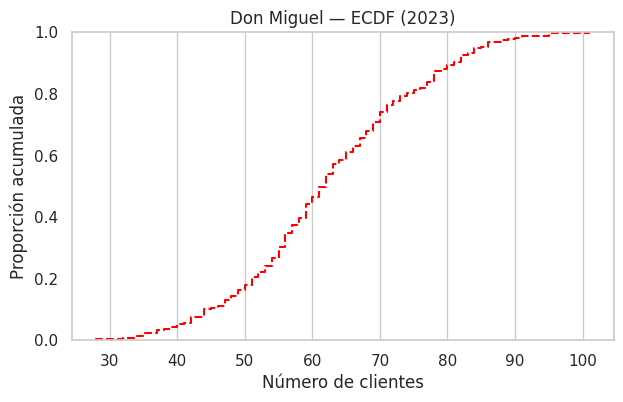

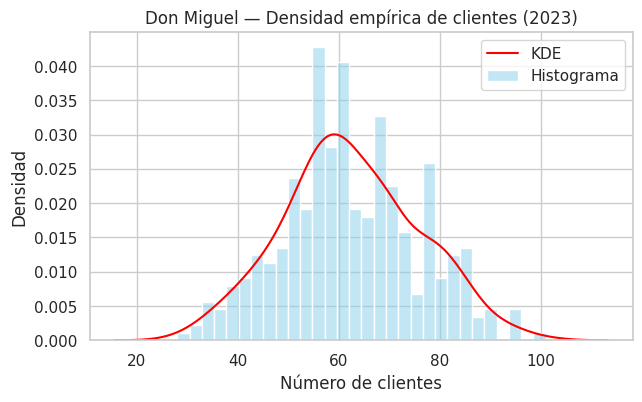

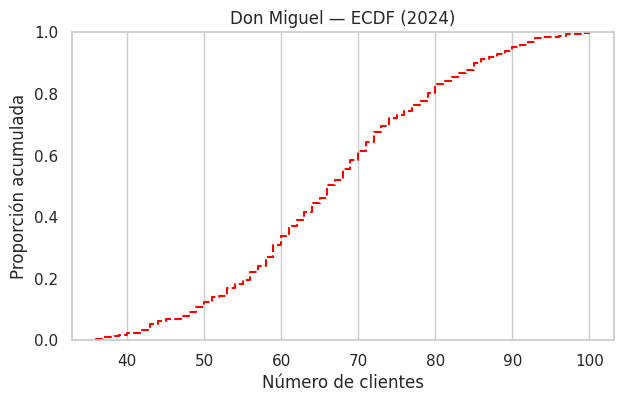

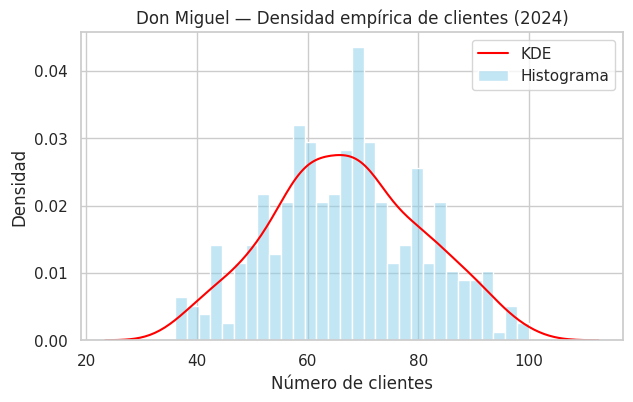

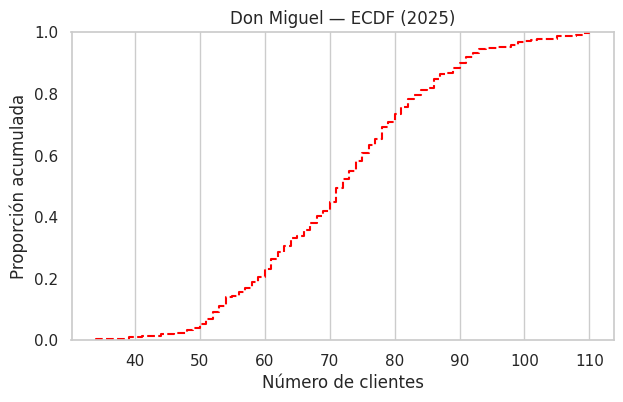

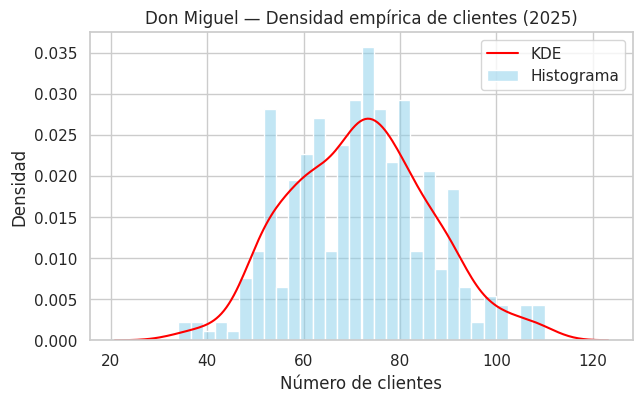

In [17]:
graficar_ecdf_y_densidad(df_miguel, "Don Miguel")

## (d) Densidad empírica conjunta de clientes

Distribución conjunta del número diario de clientes en ambos comercios (mismas fechas). El enunciado dice «ventas»; aquí se trabaja con **clientes**.

,fecha,clientes_francisco,clientes_miguel
0,2023-01-01,47,37
1,2023-01-02,65,58
2,2023-01-03,60,58
3,2023-01-04,77,62
4,2023-01-05,79,47


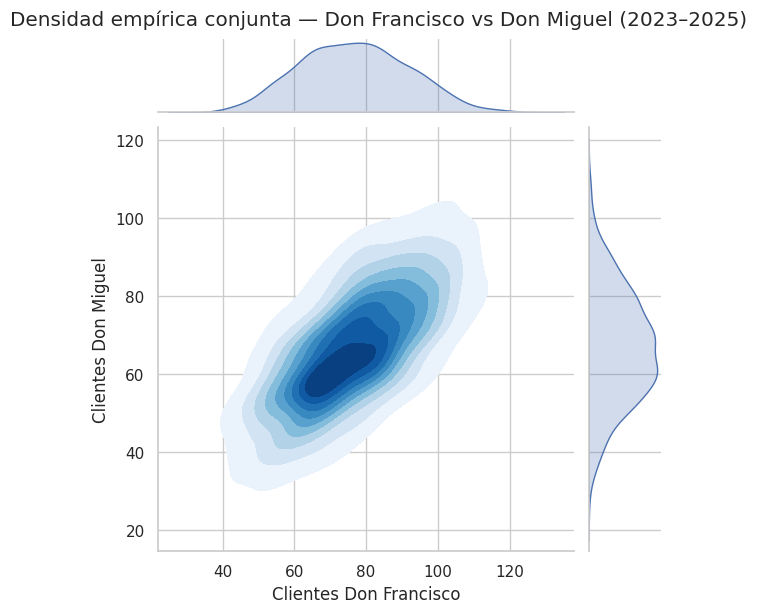

In [18]:
df_conjunto = df_francisco[["fecha", "clientes"]].merge(
    df_miguel[["fecha", "clientes"]],
    on="fecha",
    suffixes=("_francisco", "_miguel"),
)

display(df_conjunto.head())

g = sns.jointplot(
    data=df_conjunto,
    x="clientes_francisco",
    y="clientes_miguel",
    kind="kde",
    fill=True,
    cmap="Blues",
    height=6,
)
g.figure.suptitle(
    "Densidad empírica conjunta — Don Francisco vs Don Miguel (2023–2025)",
    y=1.02,
)
g.set_axis_labels("Clientes Don Francisco", "Clientes Don Miguel")
plt.show()